Exploration CNN in food Clasification

IMPORT LIBRARY

In [ ]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Reshape, RandomRotation, RandomFlip
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Input, Add
from tensorflow.keras.utils import plot_model
import tensorflow.keras as keras
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, roc_curve, auc
import seaborn as sns
from sklearn import metrics as mt
from google.colab import drive
import matplotlib.pyplot as plt
from google.colab import files
import matplotlib.pyplot as plt
import shutil
import random
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


Gdrive ke local colab

Dataset Eksploration

In [ ]:
base_dir = "/content/dataset_citra_processed_isma"

In [ ]:
classes = [
    folder for folder in os.listdir(base_dir)
    if folder not in ['0', 'dataset_citra_processed_isma']
]
print("Jumlah class:", len(classes))
print(classes)

Jumlah class: 66
['ikan', 'tempe', 'tahu', 'daging sapi', 'durian', 'daging ayam', 'tomat', 'bawang putih', 'bawang merah', 'lemon', 'kiwi', 'apel', 'wortel', 'kubis', 'pisang', 'bit', 'paprika', 'kembang kol', 'jagung', 'timun', 'cabai jalapeno', 'cabai', 'terong', 'jahe', 'ikan nila', 'ikan gabus', 'ikan mas perak', 'bawang bombay', 'mangga', 'jeruk', 'ikan patin', 'anggur', 'selada', 'pir', 'ikan perch', 'ikan belanak', 'kacang polong', 'ikan kiper', 'ikan jaguar guapote', 'ikan pisau', 'ikan lumpur', 'nanas', 'ikan bandeng', 'ikan mas kepala besar', 'lobak', 'kentang', 'bayam', 'delima', 'ikan bintik hitam', 'ubi jalar', 'kedelai', 'ikan lele', 'semangka', 'ikan betok', 'ikan gurami', 'ikan senangin', 'belut', 'ikan goby', 'ikan karper india', 'ikan mas rumput', 'ikan tawes', 'ikan tarpon indo pasifik', 'ikan kakap putih', 'ikan payus', 'udang', 'telur']


In [ ]:
class_counts = {}

for cls in classes:
    class_path = os.path.join(base_dir, cls)
    class_counts[cls] = len(os.listdir(class_path))

class_counts

{'ikan': 1258,
 'tempe': 1258,
 'tahu': 1258,
 'daging sapi': 1258,
 'durian': 1258,
 'daging ayam': 1258,
 'tomat': 1258,
 'bawang putih': 1258,
 'bawang merah': 1258,
 'lemon': 1258,
 'kiwi': 1258,
 'apel': 1258,
 'wortel': 1258,
 'kubis': 1258,
 'pisang': 1258,
 'bit': 1258,
 'paprika': 1258,
 'kembang kol': 1258,
 'jagung': 1258,
 'timun': 1258,
 'cabai jalapeno': 1258,
 'cabai': 1258,
 'terong': 1258,
 'jahe': 1258,
 'ikan nila': 1258,
 'ikan gabus': 1258,
 'ikan mas perak': 1258,
 'bawang bombay': 1258,
 'mangga': 1258,
 'jeruk': 1258,
 'ikan patin': 1258,
 'anggur': 1258,
 'selada': 1258,
 'pir': 1258,
 'ikan perch': 1258,
 'ikan belanak': 1258,
 'kacang polong': 1258,
 'ikan kiper': 1258,
 'ikan jaguar guapote': 1258,
 'ikan pisau': 1258,
 'ikan lumpur': 1258,
 'nanas': 1258,
 'ikan bandeng': 1258,
 'ikan mas kepala besar': 1258,
 'lobak': 1258,
 'kentang': 1258,
 'bayam': 1258,
 'delima': 1258,
 'ikan bintik hitam': 1258,
 'ubi jalar': 1258,
 'kedelai': 1258,
 'ikan lele': 125

In [ ]:
total_images = sum(class_counts.values())

print("Total gambar:", total_images)

Total gambar: 83028


In [ ]:
sample_class = random.choice(classes)
sample_dir = os.path.join(base_dir, sample_class)
sample_image = random.choice(os.listdir(sample_dir))
img_path = os.path.join(sample_dir, sample_image)
img = Image.open(img_path)

print("Ukuran gambar:", img.size)
print("Mode warna:", img.mode)

Ukuran gambar: (224, 224)
Mode warna: RGB


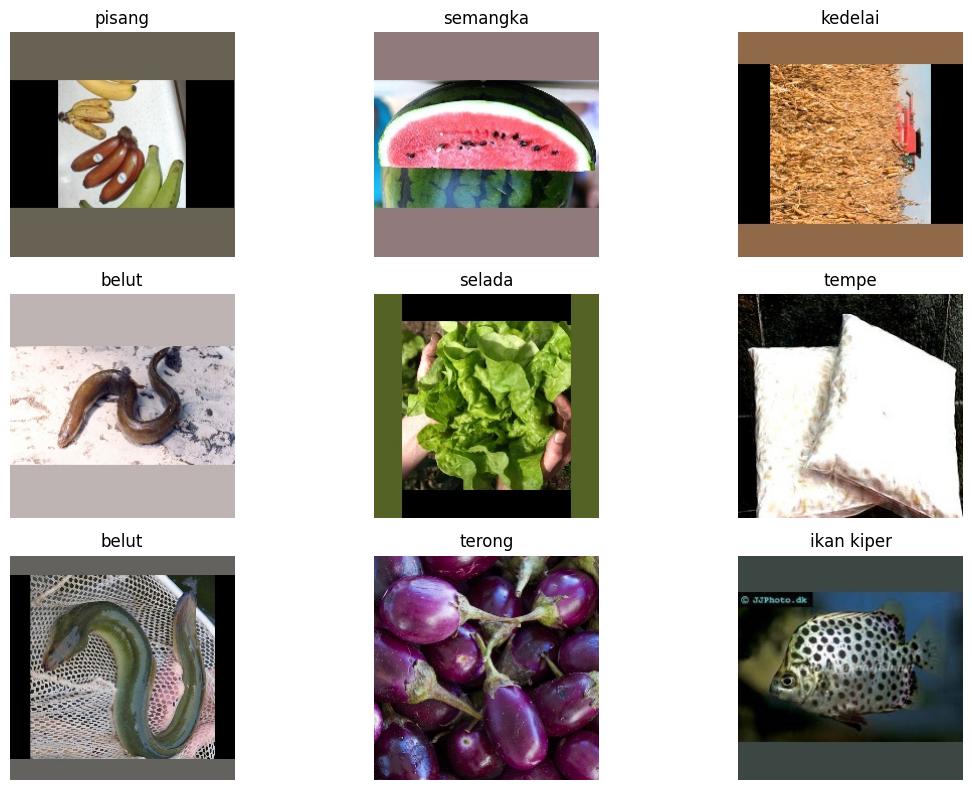

In [ ]:
plt.figure(figsize=(12,8))
for i in range(9):
    sample_class = random.choice(classes)
    sample_dir = os.path.join(base_dir, sample_class)
    sample_image = random.choice(os.listdir(sample_dir))
    img_path = os.path.join(sample_dir, sample_image)
    img = Image.open(img_path)
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(sample_class)
    plt.axis('off')

plt.tight_layout()
plt.show()

Split Dataset

In [ ]:
clean_dir = "/content/dataset_clean"

os.makedirs(clean_dir, exist_ok=True)

In [ ]:
!cp -r "/content/dataset_clean" "/content/drive/MyDrive/CAPSTONE_AI_Engginer_ISMA/"

In [ ]:
!cp -r "/content/drive/MyDrive/CAPSTONE_AI_Engginer_ISMA/dataset_clean" "/content/"

In [ ]:
base_dir = "/content/dataset_clean"

full_dataset = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    seed=42
)

Found 84300 files belonging to 66 classes.


In [ ]:
class_names = full_dataset.class_names

print("Jumlah class:", len(class_names))
print(class_names)

Jumlah class: 66
['anggur', 'apel', 'bawang bombay', 'bawang merah', 'bawang putih', 'bayam', 'belut', 'bit', 'cabai', 'cabai jalapeno', 'daging ayam', 'daging sapi', 'delima', 'durian', 'ikan', 'ikan bandeng', 'ikan belanak', 'ikan betok', 'ikan bintik hitam', 'ikan gabus', 'ikan goby', 'ikan gurami', 'ikan jaguar guapote', 'ikan kakap putih', 'ikan karper india', 'ikan kiper', 'ikan lele', 'ikan lumpur', 'ikan mas kepala besar', 'ikan mas perak', 'ikan mas rumput', 'ikan nila', 'ikan patin', 'ikan payus', 'ikan perch', 'ikan pisau', 'ikan senangin', 'ikan tarpon indo pasifik', 'ikan tawes', 'jagung', 'jahe', 'jeruk', 'kacang polong', 'kedelai', 'kembang kol', 'kentang', 'kiwi', 'kubis', 'lemon', 'lobak', 'mangga', 'nanas', 'paprika', 'pir', 'pisang', 'selada', 'semangka', 'tahu', 'telur', 'tempe', 'terong', 'timun', 'tomat', 'ubi jalar', 'udang', 'wortel']


In [ ]:
# =========================================================
# SPLIT DATASET
# 70% TRAIN
# 15% VALIDATION
# 15% TEST
# =========================================================

dataset_size = len(full_dataset)
print("Jumlah batch total:", dataset_size)

train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)

# Train dataset
train_dataset = full_dataset.take(train_size)

# Sisa dataset
temp_dataset = full_dataset.skip(train_size)

# Validation dataset
val_dataset = temp_dataset.take(val_size)

# Test dataset
test_dataset = temp_dataset.skip(val_size)


Jumlah batch total: 2635


In [ ]:
print("Train batches:", len(train_dataset))
print("Validation batches:", len(val_dataset))
print("Test batches:", len(test_dataset))

Train batches: 1844
Validation batches: 395
Test batches: 396


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


Normalize

In [ ]:
normalization_layer = layers.Rescaling(1./255)
train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)
val_dataset = val_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)
test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y)
)

Augmentasi

In [ ]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal_and_vertical"),

    layers.RandomRotation(0.2)

])

Prefetch

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

val_dataset = val_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    buffer_size=AUTOTUNE
)

Input

Augmentation

Conv2D 32

MaxPooling

Conv2D 64

MaxPooling

Conv2D 128

MaxPooling

Flatten

Dense 128

Dropout

Output 66 class

In [ ]:
model = models.Sequential([
    # Augmentasi
    data_augmentation,

    # CNN Layer 1
    layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    ),

    layers.MaxPooling2D(2,2),

    # CNN Layer 2
    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(2,2),

    # CNN Layer 3
    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(2,2),

    # Flatten
    layers.Flatten(),

    # Dense
    layers.Dense(
        128,
        activation='relu'
    ),

    # Dropout
    layers.Dropout(0.5),

    # Output
    layers.Dense(
        66,
        activation='softmax'
    )
])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Callback

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(

    train_dataset.take(200),

    validation_data=val_dataset.take(50),

    epochs=5,

    callbacks=[early_stop]
)

Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 958s 5s/step - accuracy: 0.0227 - loss: 4.2275 - val_accuracy: 0.0312 - val_loss: 4.1267
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 919s 5s/step - accuracy: 0.0445 - loss: 3.9780 - val_accuracy: 0.0787 - val_loss: 3.6043
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 892s 4s/step - accuracy: 0.0819 - loss: 3.6167 - val_accuracy: 0.1106 - val_loss: 3.2770
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 926s 4s/step - accuracy: 0.0972 - loss: 3.4005 - val_accuracy: 0.1681 - val_loss: 3.1044
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 876s 4s/step - accuracy: 0.1166 - loss: 3.2738 - val_accuracy: 0.1869 - val_loss: 2.9585


In [ ]:
test_loss, test_acc = model.evaluate(
    test_dataset.take(50)
)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

50/50 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.1931 - loss: 2.9375
Test Accuracy: 0.19312499463558197
Test Loss: 2.9375498294830322


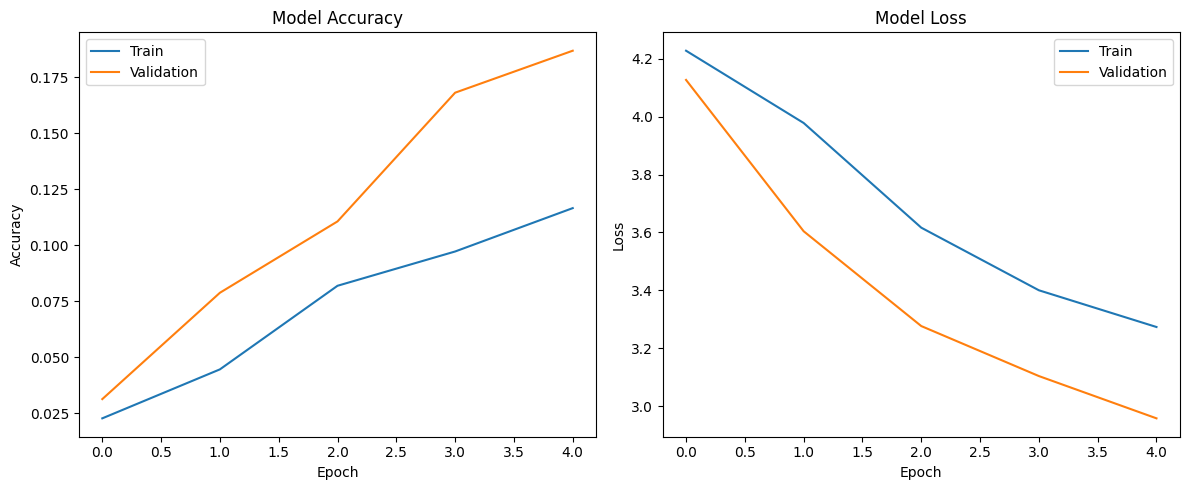

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])


# Loss
plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.tight_layout()

plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_dataset.take(50):

    predictions = model.predict(images)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 946ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 986ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 915ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 916ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 926ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 916ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 939ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 913ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 927ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 928ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 927ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
